I. Khai báo thư viện

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

II. Đọc dữ liệu

In [3]:
house_daily = pd.read_csv("HousePricingHCM_v2.csv")
grdp = pd.read_csv("hcmc_grdp_2017_2022.csv")
cpi = pd.read_csv("vietnam_cpi_worldbank_2017_2022.csv")
interest = pd.read_csv("vietnam_refinancing_rate_quarterly_2017_2022.csv")

print("House:", house_daily.shape)
print("GRDP:", grdp.shape)
print("CPI:", cpi.shape)
print("Interest:", interest.shape)

display(house_daily.head())
display(grdp.head())
display(cpi.head())
display(interest.head())

House: (1996, 10)
GRDP: (6, 5)
CPI: (6, 4)
Interest: (22, 4)


,Date,District 1,District 2,District 3,District 4,District 5,District 6,District 7,District 8,District 9
0,01/01/2017,89.71,45.02,123.16,81.82,79.82,75.96,19.51,44.81,23.43
1,01/02/2017,89.71,45.02,123.16,81.82,79.82,75.96,19.51,44.81,23.43
2,01/03/2017,90.70,45.99,123.95,82.14,80.71,76.44,19.17,43.64,24.31
3,01/04/2017,91.55,44.90,124.50,84.43,82.92,78.13,19.32,44.15,23.48
4,01/05/2017,92.88,47.56,124.90,80.83,80.85,77.85,18.00,41.22,22.65


,Year,GRDP_Hien_Hanh_Ty_Dong,GRDP_So_Sanh_2010_Ty_Dong,Tang_Truong_Pct,COVID_Phase
0,2017,NaN,842376,7.88,Pre-COVID
1,2018,NaN,907058,7.90,Pre-COVID
2,2019,NaN,978308,7.79,Pre-COVID
3,2020,NaN,991424,1.39,COVID Wave 1&2
4,2021,NaN,924367,-6.78,COVID Wave 4 (HCM phong tỏa)


,Year,CPI_Annual_Pct,COVID_Phase,Note
0,2017,3.520257,Pre-COVID,Lạm phát ổn định mức trung bình
1,2018,3.539628,Pre-COVID,Lạm phát ổn định mức trung bình
2,2019,2.795824,Pre-COVID,Lạm phát thấp nhất giai đoạn trước COVID
3,2020,3.220934,COVID Wave 1&2,Lạm phát tăng nhẹ dù kinh tế chậm lại
4,2021,1.834716,COVID Wave 4 (HCM phong tỏa),Lạm phát thấp nhất 2017-2022 - cầu tiêu dùng y...


,Quarter,Effective_Date,Refinancing_Rate_Pct,Note
0,2017-Q1,01/01/2017,6.50,Duy trì ổn định
1,2017-Q2,01/04/2017,6.25,Giảm 0.25% từ 10/07/2017
2,2017-Q3,10/07/2017,6.25,Cắt giảm lần đầu 2017
3,2017-Q4,01/10/2017,6.25,Duy trì
4,2018-Q1,01/01/2018,6.25,Duy trì ổn định


III. Kiểm tra và chuẩn hóa dữ liệu giá nhà

1. Thông tin dữ liệu

In [4]:
print("Các cột:", house_daily.columns.tolist())
print("\nThông tin dữ liệu:")
house_daily.info()

Các cột: ['Date', 'District 1', 'District 2', 'District 3', 'District 4', 'District 5', 'District 6', 'District 7', 'District 8', 'District 9']

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1996 non-null   object 
 1   District 1  1996 non-null   float64
 2   District 2  1996 non-null   float64
 3   District 3  1996 non-null   float64
 4   District 4  1996 non-null   float64
 5   District 5  1996 non-null   float64
 6   District 6  1996 non-null   float64
 7   District 7  1996 non-null   float64
 8   District 8  1996 non-null   float64
 9   District 9  1996 non-null   float64
dtypes: float64(9), object(1)
memory usage: 156.1+ KB


2. Kiểm tra các giá trị thiếu và trùng

In [5]:
print("\nGiá trị thiếu:")
display(house_daily.isna().sum().to_frame("missing"))

print("Số dòng trùng:", house_daily.duplicated().sum())


Giá trị thiếu:


,missing
Date,0
District 1,0
District 2,0
District 3,0
District 4,0
District 5,0
District 6,0
District 7,0
District 8,0
District 9,0


Số dòng trùng: 0


3. Chuyển cột Date sang kiểu ngày tháng

In [6]:
house_daily["Date"] = pd.to_datetime(
    house_daily["Date"],
    format="%m/%d/%Y",
    errors="coerce" # khi giá trị k đúng định dạng tự chuyển thÀNH NaT
)
if house_daily["Date"].isna().any():
    raise ValueError("Có ngày không chuyển đổi được. Hãy kiểm tra cột Date.")

--> dữ liệu đã chuyển đổi thành công 

4. Làm sạch dữ liệu: xóa dòng trùng, sắp xếp theo thời gian, đặt Date thành chỉ mục

In [7]:
house_daily = (
    house_daily
    .drop_duplicates()
    .sort_values("Date")
    .set_index("Date")
)

5. Chuyển các cột về giá dạng số

In [8]:
for col in house_daily.columns:
    house_daily[col] = pd.to_numeric(house_daily[col], errors="coerce")    

6. Kiểm tra kích thước dữ liệu

In [9]:
print("Kích thước:", house_daily.shape)

Kích thước: (1996, 9)


7. Kiểm tra thời gian nghiên cứu

In [10]:
print("Thời gian:", house_daily.index.min(), "đến", house_daily.index.max())

Thời gian: 2017-01-01 00:00:00 đến 2022-06-20 00:00:00


8. Kiểm tra các giá trị thiếu

In [11]:
print("Tổng giá trị thiếu:", house_daily.isna().sum().sum())
house_daily.head()

Tổng giá trị thiếu: 0


,District 1,District 2,District 3,District 4,District 5,District 6,District 7,District 8,District 9
Date,,,,,,,,,
2017-01-01,89.71,45.02,123.16,81.82,79.82,75.96,19.51,44.81,23.43
2017-01-02,89.71,45.02,123.16,81.82,79.82,75.96,19.51,44.81,23.43
2017-01-03,90.70,45.99,123.95,82.14,80.71,76.44,19.17,43.64,24.31
2017-01-04,91.55,44.90,124.50,84.43,82.92,78.13,19.32,44.15,23.48
2017-01-05,92.88,47.56,124.90,80.83,80.85,77.85,18.00,41.22,22.65


NHẬN XÉT: dữ liệu được tiền xử lý bằng cách chuyển cột Date sang định dạng ngày tháng, loại bỏ các giá trị trùng lặp, tiến hành sắp xếp theo thời gian để thuận tiện phân tích theo chuỗi. Các cột giá được chuyển sang dữ liệu số và kiểm tra lại các giá trị thiếu. Kết quả sau khi xử lý thấy dữ liệu có 1.996 quan sát, từ giai đoạn 01/01/2017 đến 20/06/2022. Không có giá trị thiếu và sẵn sàn tiến hành bước phân tích tiếp theo

IV. Chuyển dữ liệu giá nhà từ ngày sang quý

In [12]:
house_quarterly = house_daily.resample("QE").mean()
house_quarterly.index = house_quarterly.index.to_period("Q").astype(str)
house_quarterly.index.name = "Quarter"

print("Số quý:", house_quarterly.shape[0])
print("Số quận:", house_quarterly.shape[1])
house_quarterly.head()

Số quý: 22
Số quận: 9


,District 1,District 2,District 3,District 4,District 5,District 6,District 7,District 8,District 9
Quarter,,,,,,,,,
2017Q1,95.738444,47.291444,118.340556,66.807556,82.883444,78.754333,29.766111,44.819556,25.415333
2017Q2,97.781758,46.137253,94.228132,62.532967,103.451758,61.532308,47.990220,49.959780,23.403297
2017Q3,124.149891,45.472065,97.887174,69.412717,120.747500,57.912826,49.278152,52.710978,29.143261
2017Q4,122.509457,43.994891,100.323152,68.102174,121.627283,58.875543,50.096196,54.687500,30.724348
2018Q1,119.523889,41.693778,102.024333,62.864444,90.835333,65.321667,52.403556,57.136111,31.888444


Theo ban đầu thì dữ liệu được ghi nhận theo ngày nên được tổng hợp theo quý bằng cách tính giá trung bình của từng quận sau mỗi quý. sau khi chuyển đổi, bộ dữ liệu gồm 22 quý với 9 quận, dữ liệu hoàn toàn phù hợp để kết hợp với các dữ liệu vĩ mô như drdp, cpi, lãi suất và COVID ( vốn dĩ các dữ liệu này đều được thu thập theo công bố là quý, giúp nhất quán hơn trong quá trình phân tích

1. Chuyển đổi dữ liệu từ dạng rộng sang dạng dài

In [13]:
house_long = (
    house_quarterly
    .reset_index()
    .melt(
        id_vars="Quarter",
        var_name="District",
        value_name="AvgPrice"
    )
)

2. Chuyển đổi AvgPrice sang kiểu số

In [14]:
house_long["AvgPrice"] = pd.to_numeric(house_long["AvgPrice"], errors="coerce")
if (house_long["AvgPrice"] <= 0).any():
    raise ValueError("AvgPrice có giá trị không dương.")

3. Tạo biến logarit của giá nhà

In [15]:
house_long["log_price"] = np.log(house_long["AvgPrice"])

In [16]:
print("Kích thước dạng dài:", house_long.shape)
house_long.head(10)

Kích thước dạng dài: (198, 4)


,Quarter,District,AvgPrice,log_price
0,2017Q1,District 1,95.738444,4.561620
1,2017Q2,District 1,97.781758,4.582738
2,2017Q3,District 1,124.149891,4.821490
3,2017Q4,District 1,122.509457,4.808188
4,2018Q1,District 1,119.523889,4.783516
5,2018Q2,District 1,134.142747,4.898905
6,2018Q3,District 1,142.920870,4.962291
7,2018Q4,District 1,148.704130,5.001959
8,2019Q1,District 1,176.767667,5.174836
9,2019Q2,District 1,220.130659,5.394221


Dữ liệu giá nhà sau khi tổng hợp theo quý được chuyển từ dạng rộng sang dạng dài nhằm phục vụ việc kết hợp với các biến kinh tế vĩ mô và xây dựng mô hình hồi quy. Sau khi chuyển đổi, bộ dữ liệu gồm 198 quan sát, tương ứng với 22 quý và 9 quận. Đồng thời, biến log_price được tạo bằng phép biến đổi logarit tự nhiên của giá nhà trung bình để làm biến phụ thuộc trong mô hình, giúp giảm ảnh hưởng của các giá trị lớn và cải thiện khả năng phân tích thống kê.

V. Chuẩn hóa dữ liệu GRDP

In [17]:
print(grdp.columns.tolist())
display(grdp)

['Year', 'GRDP_Hien_Hanh_Ty_Dong', 'GRDP_So_Sanh_2010_Ty_Dong', 'Tang_Truong_Pct', 'COVID_Phase']


,Year,GRDP_Hien_Hanh_Ty_Dong,GRDP_So_Sanh_2010_Ty_Dong,Tang_Truong_Pct,COVID_Phase
0,2017,NaN,842376,7.88,Pre-COVID
1,2018,NaN,907058,7.90,Pre-COVID
2,2019,NaN,978308,7.79,Pre-COVID
3,2020,NaN,991424,1.39,COVID Wave 1&2
4,2021,NaN,924367,-6.78,COVID Wave 4 (HCM phong tỏa)
5,2022,1479227.0,1021894,9.03,Phục hồi hậu COVID


Lấy dữ liệu GRDP

In [18]:
grdp_year = grdp[[
    "Year",
    "GRDP_So_Sanh_2010_Ty_Dong",
    "Tang_Truong_Pct"
]].copy()

Đổi tên cột

In [19]:
grdp_year = grdp_year.rename(columns={
    "GRDP_So_Sanh_2010_Ty_Dong": "GRDP",
    "Tang_Truong_Pct": "GRDP_growth"
})

lặp mỗi năm 4 lần

In [20]:
grdp_quarterly = grdp_year.loc[
    grdp_year.index.repeat(4)
].reset_index(drop=True)


Tạo cột Quarter

In [21]:
grdp_quarterly["Quarter"] = [
    f"{year}Q{q}"
    for year in grdp_year["Year"]
    for q in range(1, 5)
]

Giữ lại các cột cần thiết

In [22]:
grdp_quarterly = grdp_quarterly[
    ["Quarter", "GRDP", "GRDP_growth"]
]
grdp_quarterly.head()

,Quarter,GRDP,GRDP_growth
0,2017Q1,842376,7.88
1,2017Q2,842376,7.88
2,2017Q3,842376,7.88
3,2017Q4,842376,7.88
4,2018Q1,907058,7.90


VI. Chuẩn hóa CPI

In [23]:
cpi_year = cpi[["Year", "CPI_Annual_Pct"]].copy()

Đổi tên cột

In [24]:
cpi_year = cpi_year.rename(columns={
    "CPI_Annual_Pct": "CPI"
})

Tạo dữ liệu theo quý

In [25]:
cpi_quarterly = cpi_year.loc[
    cpi_year.index.repeat(4)
].reset_index(drop=True)

# Tạo Quarter
cpi_quarterly["Quarter"] = [
    f"{year}Q{q}"
    for year in cpi_year["Year"]
    for q in range(1, 5)
]

In [26]:
cpi_quarterly = cpi_quarterly[
    ["Quarter", "CPI"]
]
cpi_quarterly.head()

,Quarter,CPI
0,2017Q1,3.520257
1,2017Q2,3.520257
2,2017Q3,3.520257
3,2017Q4,3.520257
4,2018Q1,3.539628


 VII. Chuẩn hóa Lãi suất

In [27]:
interest = interest[
    ["Quarter", "Refinancing_Rate_Pct"]
].copy()


Đổi tên cột

In [28]:
interest = interest.rename(columns={
    "Refinancing_Rate_Pct": "LaiSuat"
})

Chuẩn hóa theo định dạng quý

In [29]:
interest["Quarter"] = (
    interest["Quarter"]
    .astype(str)
    .str.strip()
    .str.replace("-", "", regex=False)
)


Chuyển lãi suất sang kiểu số

In [30]:
interest["Quarter"] = (
    interest["Quarter"]
    .astype(str)
    .str.strip()
    .str.replace("-", "", regex=False)
)
interest.head()

,Quarter,LaiSuat
0,2017Q1,6.50
1,2017Q2,6.25
2,2017Q3,6.25
3,2017Q4,6.25
4,2018Q1,6.25


VIII. Tạo biến thời gian COVID và nhóm quận

Tách năm và số quý tạo từ cột Quarter

In [31]:
house_long["Year"] = house_long["Quarter"].str[:4].astype(int)
house_long["Quarter_num"] = house_long["Quarter"].str[-1].astype(int)

Tạo chỉ số thời gian

In [32]:
house_long["time_index"] = (
    (house_long["Year"] - 2017) * 4
    + house_long["Quarter_num"] - 1
)

Tạo biến Covid

In [33]:
covid_quarters = [
    "2020Q1", "2020Q2", "2020Q3", "2020Q4",
    "2021Q1", "2021Q2", "2021Q3"
]
house_long["covid_broad"] = (
    house_long["Quarter"]
    .isin(covid_quarters)
    .astype(int)
)

Tìm tốc độ tăng trưởng giá của hai quận cao nhất

In [34]:
house_long = house_long.sort_values(
    ["District", "time_index"]
)
first_price = (
    house_long
    .groupby("District")
    .first()["AvgPrice"]
)
last_price = (
    house_long
    .groupby("District")
    .last()["AvgPrice"]
)
district_growth = (
    (last_price / first_price - 1) * 100
).sort_values(ascending=False)

display(district_growth)

District
District 7    204.129520
District 9    173.705190
District 5    132.405793
District 1    129.339866
District 8    112.558506
District 2     83.878952
District 4     61.043920
District 3     50.544072
District 6     36.135327
Name: AvgPrice, dtype: float64

Biến nhóm quận

In [35]:
house_long["is_fast_growth"] = (
    house_long["District"]
    .isin(["District 7", "District 9"])
    .astype(int)
)
house_long.head()

,Quarter,District,AvgPrice,log_price,Year,Quarter_num,time_index,covid_broad,is_fast_growth
0,2017Q1,District 1,95.738444,4.561620,2017,1,0,0,0
1,2017Q2,District 1,97.781758,4.582738,2017,2,1,0,0
2,2017Q3,District 1,124.149891,4.821490,2017,3,2,0,0
3,2017Q4,District 1,122.509457,4.808188,2017,4,3,0,0
4,2018Q1,District 1,119.523889,4.783516,2018,1,4,0,0


IV. Ghép dữ liệu giá nhà với các biến vĩ mô

In [36]:
house_data = (
    house_long
    .merge(grdp_quarterly, on="Quarter", how="left")
    .merge(cpi_quarterly, on="Quarter", how="left")
    .merge(interest, on="Quarter", how="left")
    .sort_values(["District", "time_index"])
    .reset_index(drop=True)
)

print("Kích thước:", house_data.shape)
house_data.head()

Kích thước: (198, 13)


,Quarter,District,AvgPrice,log_price,Year,Quarter_num,time_index,covid_broad,is_fast_growth,GRDP,GRDP_growth,CPI,LaiSuat
0,2017Q1,District 1,95.738444,4.561620,2017,1,0,0,0,842376,7.88,3.520257,6.50
1,2017Q2,District 1,97.781758,4.582738,2017,2,1,0,0,842376,7.88,3.520257,6.25
2,2017Q3,District 1,124.149891,4.821490,2017,3,2,0,0,842376,7.88,3.520257,6.25
3,2017Q4,District 1,122.509457,4.808188,2017,4,3,0,0,842376,7.88,3.520257,6.25
4,2018Q1,District 1,119.523889,4.783516,2018,1,4,0,0,907058,7.90,3.539628,6.25


Kiểm tra dữ liệu sau khi ghép

Danh sách cần kiểm tra

In [37]:
macro_columns = ["GRDP", "GRDP_growth", "CPI", "LaiSuat"]

kiểm tra các giá trị thiếu

In [38]:
print("Số giá trị thiếu:")
house_data.isnull().sum()

Số giá trị thiếu:


Quarter           0
District          0
AvgPrice          0
log_price         0
Year              0
Quarter_num       0
time_index        0
covid_broad       0
is_fast_growth    0
GRDP              0
GRDP_growth       0
CPI               0
LaiSuat           0
dtype: int64

nhìn chung không có dữ liệu bị thiếu

In [39]:
house_data.to_csv('finaldata.csv', index=False)
print("\nHoàn tất", house_data.shape)
print(house_data.head())


Hoàn tất (198, 13)
  Quarter    District    AvgPrice  log_price  Year  Quarter_num  time_index  \
0  2017Q1  District 1   95.738444   4.561620  2017            1           0   
1  2017Q2  District 1   97.781758   4.582738  2017            2           1   
2  2017Q3  District 1  124.149891   4.821490  2017            3           2   
3  2017Q4  District 1  122.509457   4.808188  2017            4           3   
4  2018Q1  District 1  119.523889   4.783516  2018            1           4   

   covid_broad  is_fast_growth    GRDP  GRDP_growth       CPI  LaiSuat  
0            0               0  842376         7.88  3.520257     6.50  
1            0               0  842376         7.88  3.520257     6.25  
2            0               0  842376         7.88  3.520257     6.25  
3            0               0  842376         7.88  3.520257     6.25  
4            0               0  907058         7.90  3.539628     6.25  


X. Kiểm tra chất lượng dữ liệu

In [40]:
print("Shape:", house_data.shape)
print("Số quận:", house_data["District"].nunique())
print("Số quý:", house_data["Quarter"].nunique())
print("Số dòng trùng:", house_data.duplicated().sum())

Shape: (198, 13)
Số quận: 9
Số quý: 22
Số dòng trùng: 0


 Kiểm tra kiểu dữ liệu của các thuộc tính

In [41]:
house_data.dtypes

Quarter            object
District           object
AvgPrice          float64
log_price         float64
Year                int64
Quarter_num         int64
time_index          int64
covid_broad         int64
is_fast_growth      int64
GRDP                int64
GRDP_growth       float64
CPI               float64
LaiSuat           float64
dtype: object

Kiểm tra dữ liệu thiếu

In [42]:
house_data.isna().sum()

Quarter           0
District          0
AvgPrice          0
log_price         0
Year              0
Quarter_num       0
time_index        0
covid_broad       0
is_fast_growth    0
GRDP              0
GRDP_growth       0
CPI               0
LaiSuat           0
dtype: int64

In [43]:
quarters_by_district = (
    house_data
    .groupby("District")["Quarter"]
    .nunique()
)

print("\nSố quý của từng quận:")
display(
    quarters_by_district.to_frame("Số quý")
)


Số quý của từng quận:


,Số quý
District,
District 1,22
District 2,22
District 3,22
District 4,22
District 5,22
District 6,22
District 7,22
District 8,22
District 9,22


Nhận xét: dữ liệu có 198 số quan sát bao gồm 9 quận, 22 quý, nhìn chung dữ liệu không có số giá trị thiếu và trùng

XI. Thống kê mô tả

In [44]:
numeric_cols = [
    "AvgPrice", "log_price", "GRDP", "GRDP_growth",
    "CPI", "LaiSuat", "covid_broad", "is_fast_growth"
]
display(house_data[numeric_cols].describe().T)

district_summary = (
    house_data
    .groupby("District")["AvgPrice"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(district_summary.round(2))

,count,mean,std,min,25%,50%,75%,max
AvgPrice,198.0,105.867666,55.248818,23.403297,66.993335,90.694560,126.484755,2.635533e+02
log_price,198.0,4.533796,0.510627,3.152877,4.204588,4.507497,4.840065,5.574255e+00
GRDP,198.0,937178.181818,57799.434353,842376.000000,907058.000000,924367.000000,991424.000000,1.021894e+06
GRDP_growth,198.0,4.126364,5.738647,-6.780000,1.390000,7.790000,7.900000,9.030000e+00
CPI,198.0,2.998111,0.607939,1.834716,2.795824,3.220934,3.520257,3.539628e+00
LaiSuat,198.0,5.306818,1.041459,4.000000,4.000000,6.000000,6.250000,6.500000e+00
covid_broad,198.0,0.318182,0.466951,0.000000,0.000000,0.000000,1.000000,1.000000e+00
is_fast_growth,198.0,0.222222,0.416794,0.000000,0.000000,0.000000,0.000000,1.000000e+00


,count,mean,median,std,min,max
District,,,,,,
District 1,22,190.92,219.85,55.65,95.74,263.55
District 3,22,159.10,179.76,39.45,94.23,205.24
District 5,22,155.18,160.07,39.46,82.88,199.12
District 4,22,93.50,107.59,21.08,62.53,128.08
District 6,22,88.20,92.91,17.87,57.91,109.34
District 8,22,76.79,82.51,17.09,44.82,95.27
District 7,22,73.48,78.66,17.62,29.77,90.53
District 2,22,66.27,72.03,16.51,41.69,91.75
District 9,22,49.36,55.85,15.26,23.40,69.56


1. Biến AvgPrice (Giá nhà trung bình)
Giá nhà trung bình đạt 105,87 triệu đồng/m².
Giá thấp nhất là 23,40 triệu đồng/m², trong khi cao nhất đạt 263,55 triệu đồng/m², cho thấy sự chênh lệch khá lớn giữa các quận.
Độ lệch chuẩn 55,25 triệu đồng/m² phản ánh mức độ phân tán tương đối cao của giá nhà.
2. Biến log_price
Giá trị trung bình là 4,53, với độ lệch chuẩn 0,51.
Việc lấy log giúp dữ liệu giá nhà ổn định hơn và giảm ảnh hưởng của các giá trị quá lớn.
3. Biến GRDP
GRDP trung bình đạt 937.178 tỷ đồng, dao động từ 842.376 đến 1.021.894 tỷ đồng.
Độ lệch chuẩn khoảng 57.799 tỷ đồng, phản ánh quy mô kinh tế của TP.HCM có sự thay đổi qua các năm.
4. Biến GRDP_growth
Tốc độ tăng trưởng GRDP trung bình là 4,13%.
Có giai đoạn tăng trưởng âm (-6,78%), trong khi mức cao nhất đạt 9,03%, phản ánh tác động của các biến động kinh tế, đặc biệt trong thời kỳ dịch COVID-19.
5. Biến CPI
CPI trung bình là 3,00%, dao động từ 1,83% đến 3,54%.
Độ lệch chuẩn chỉ 0,61, cho thấy lạm phát tương đối ổn định trong giai đoạn nghiên cứu.
6. Biến LaiSuat
Lãi suất trung bình là 5,31%.
Dao động từ 4% đến 6,5%, phản ánh sự điều chỉnh chính sách tiền tệ của Ngân hàng Nhà nước theo từng thời kỳ.
7. Biến covid_broad
Giá trị trung bình là 0,318, nghĩa là khoảng 31,8% số quan sát thuộc giai đoạn chịu ảnh hưởng của COVID-19.
Đây là biến giả nên chỉ nhận giá trị 0 hoặc 1.
8. Biến is_fast_growth
Giá trị trung bình là 0,222, tương đương khoảng 22,2% số quan sát thuộc nhóm quận có tốc độ tăng giá nhanh.
Biến này cũng là biến giả với hai giá trị 0 và 1.

XII. Phân phối và ngoại lai

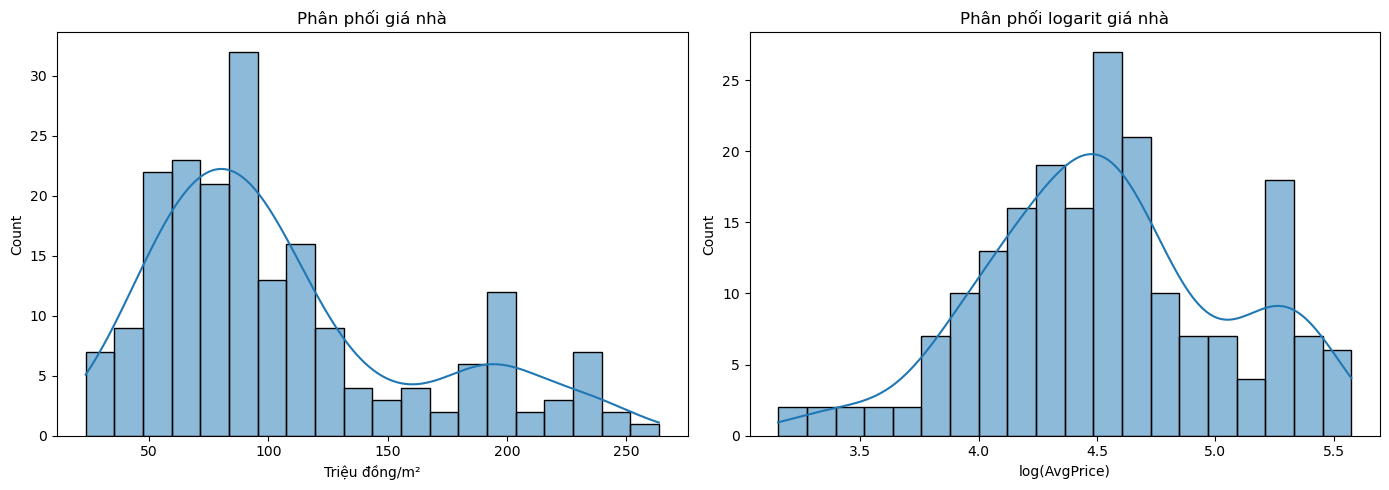

Skewness AvgPrice: 1.002
Skewness log_price: -0.008


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(house_data["AvgPrice"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Phân phối giá nhà")
axes[0].set_xlabel("Triệu đồng/m²")

sns.histplot(house_data["log_price"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Phân phối logarit giá nhà")
axes[1].set_xlabel("log(AvgPrice)")

plt.tight_layout()
plt.show()

print("Skewness AvgPrice:", round(house_data["AvgPrice"].skew(), 3))
print("Skewness log_price:", round(house_data["log_price"].skew(), 3))

Biểu đồ histogram của biến AvgPrice cho thấy dữ liệu có phân phối lệch phải do tồn tại một số quan sát có giá nhà rất cao, với hệ số lệch Skewness = 1,002. Sau khi thực hiện phép biến đổi logarit, phân phối của log_price trở nên cân đối hơn và hệ số lệch giảm xuống -0,008, gần bằng 0. Điều này cho thấy phép biến đổi log đã giúp dữ liệu gần với phân phối chuẩn, giảm ảnh hưởng của các giá trị ngoại lai và phù hợp hơn cho việc xây dựng mô hình hồi quy.

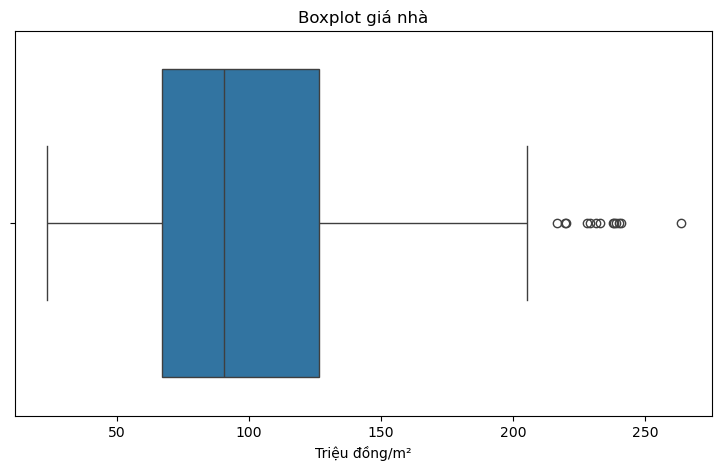

Q1: 66.99333455433455
Q3: 126.48475543478261
IQR: 59.49142088044806
Cận dưới: -22.24379676633754
Cận trên: 215.7218867554547
Số ngoại lai: 13


,Quarter,District,AvgPrice
11,2019Q4,District 1,263.553261
10,2019Q3,District 1,241.048370
20,2022Q1,District 1,240.051222
17,2021Q2,District 1,239.147143
19,2021Q4,District 1,238.484348
18,2021Q3,District 1,237.827826
12,2020Q1,District 1,232.874286
16,2021Q1,District 1,231.359222
15,2020Q4,District 1,229.070769
14,2020Q3,District 1,227.971087


In [46]:
plt.figure(figsize=(9, 5))
sns.boxplot(x=house_data["AvgPrice"])
plt.title("Boxplot giá nhà")
plt.xlabel("Triệu đồng/m²")
plt.show()

Q1 = house_data["AvgPrice"].quantile(0.25)
Q3 = house_data["AvgPrice"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = house_data[
    (house_data["AvgPrice"] < lower)
    | (house_data["AvgPrice"] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Cận dưới:", lower)
print("Cận trên:", upper)
print("Số ngoại lai:", len(outliers))

display(
    outliers[["Quarter", "District", "AvgPrice"]]
    .sort_values("AvgPrice", ascending=False)
)

Giá trị ngoại lai phù hợp với thị trường, nên sẽ giữ lại và sử dụng log_price để giảm ảnh hưởng của giá trị cao 

XIII. So sanh giá giữa các quận

1. Tính giá nhà trung bình theo từng quận

In [47]:
district_mean = (
    house_data
    .groupby("District")["AvgPrice"]
    .mean()
    .sort_values()
)


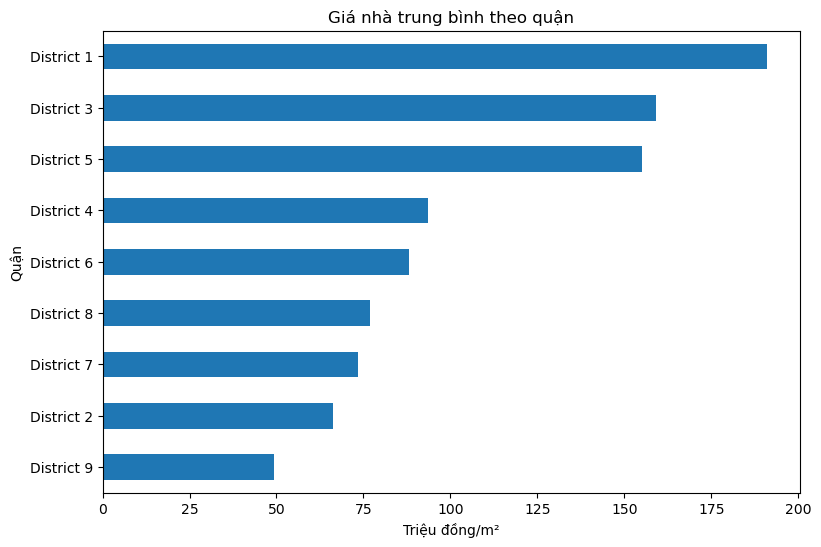

In [48]:
district_mean.plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Giá nhà trung bình theo quận")
plt.xlabel("Triệu đồng/m²")
plt.ylabel("Quận")
plt.show()

Biểu đồ cho thấy sự chênh lệch rõ ràng về giá nhà trung bình của các quận

XIV. Xu hướng giá nhà theo thời gian

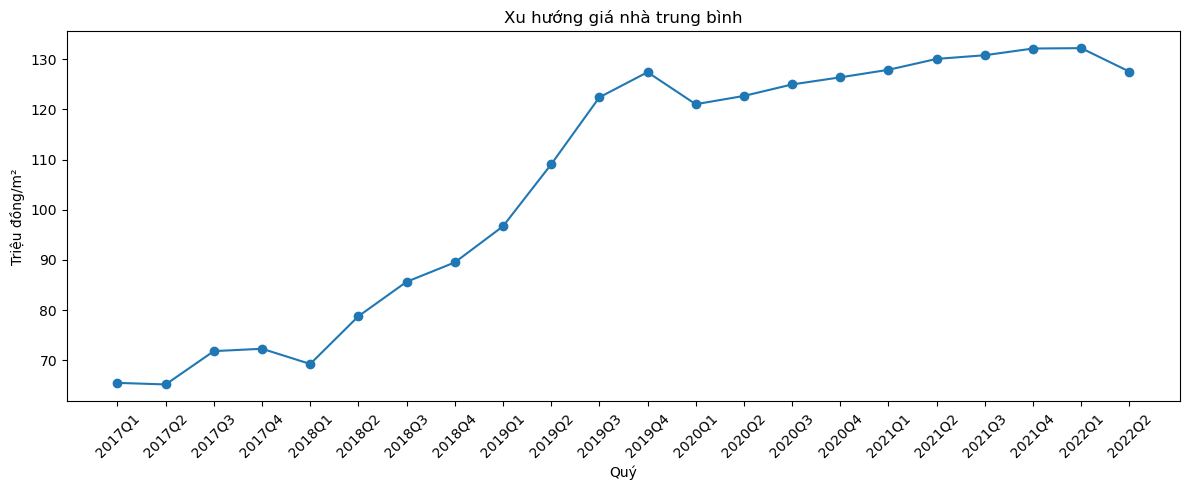

In [49]:
price_time = (
    house_data
    .sort_values("time_index")
    .groupby("Quarter", sort=False)["AvgPrice"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(price_time.index, price_time.values, marker="o")
plt.title("Xu hướng giá nhà trung bình")
plt.xlabel("Quý")
plt.ylabel("Triệu đồng/m²")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Xu hướng giá nhà trung bình toàn TP.HCM tăng liên tục. Giai đoạn 2017–2019 ghi nhận đà tăng ổn định. Từ năm 2020, dù COVID-19 bùng phát, giá nhà không giảm mà tiếp tục tăng, có thể do lãi suất ở mức thấp kỷ lục khiến dòng tiền dịch chuyển vào bất động sản. Từ cuối 2021 đến 2022, giá tăng nhanh hơn khi thị trường phục hồi sau phong tỏa, phản ánh nhu cầu bị dồn nén trong giai đoạn dịch.

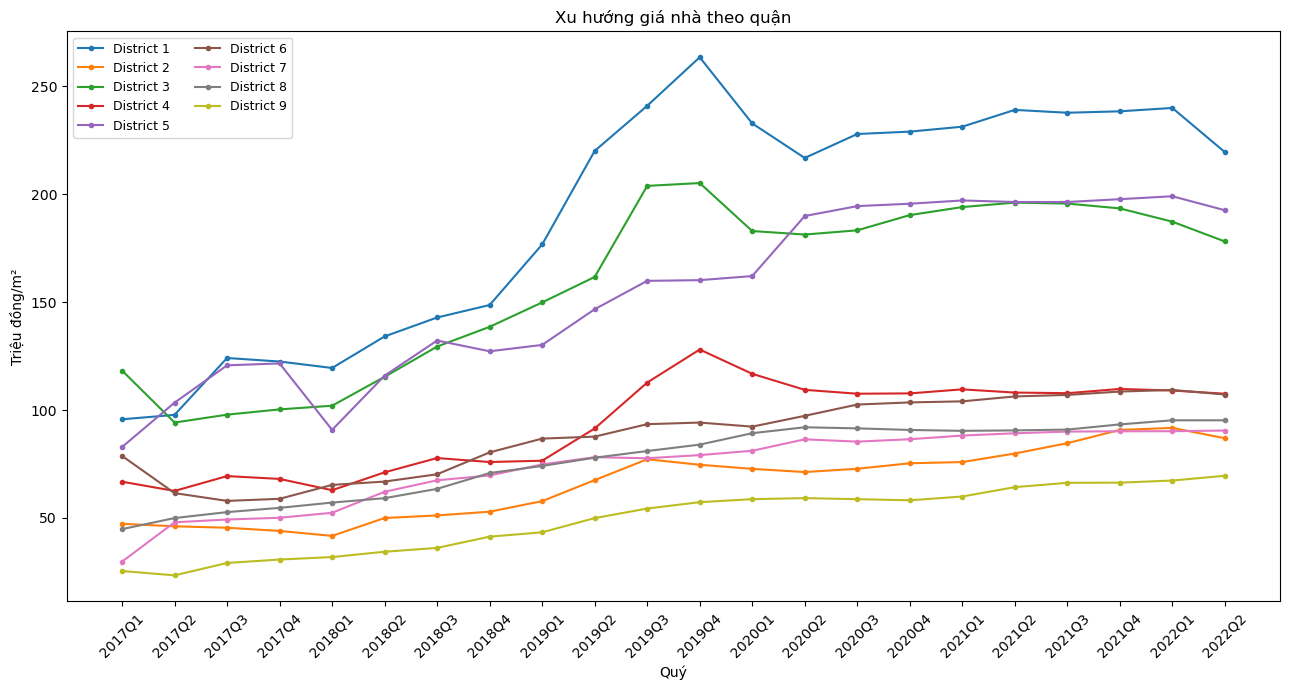

In [50]:
plt.figure(figsize=(13, 7))

for district, group in house_data.groupby("District"):
    group = group.sort_values("time_index")
    plt.plot(
        group["Quarter"],
        group["AvgPrice"],
        marker="o",
        markersize=3,
        label=district
    )

plt.title("Xu hướng giá nhà theo quận")
plt.xlabel("Quý")
plt.ylabel("Triệu đồng/m²")
plt.xticks(rotation=45)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

Biểu đồ đường cho thấy xu hướng tăng giá diễn ra ở tất cả 9 quận nhưng với tốc độ và biên độ khác nhau. Quận 1, Quận 3 và Quận 5 duy trì mức giá cao và có biến động lớn hơn. Quận 7 và Quận 9 xuất phát từ mức giá thấp nhưng có tốc độ tăng dốc nhất, phản ánh làn sóng đô thị hóa tại các khu vực ngoại ô. Đáng chú ý, hầu hết các quận đều có xu hướng tăng tốc từ năm 2021 trở đi, trùng với giai đoạn mở cửa sau phong tỏa và dòng vốn đầu tư quay trở lại thị trường.

XV. Tốc độ tăng giá đầu kỳ-cuối kỳ

1. tính tốc độ tăng giá của từng quận:
   
Tốc độ tăng = (Giá cuối kỳ / Giá đầu kỳ − 1) × 100%

In [51]:
total_growth = (
    house_data
    .sort_values("time_index")
    .groupby("District")["AvgPrice"]
    .agg(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
    .sort_values(ascending=False)
)

In [52]:
display(
    total_growth
    .round(2)
    .to_frame("Tốc độ tăng (%)")
)


,Tốc độ tăng (%)
District,
District 7,204.13
District 9,173.71
District 5,132.41
District 1,129.34
District 8,112.56
District 2,83.88
District 4,61.04
District 3,50.54
District 6,36.14


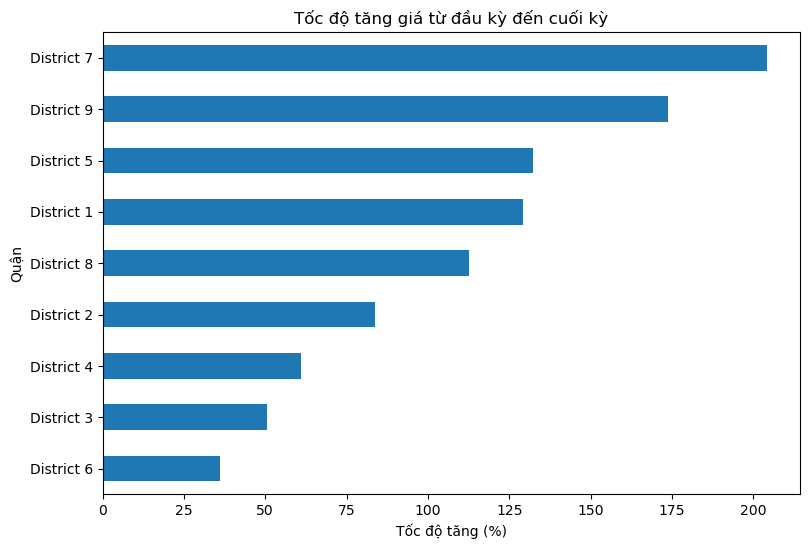

In [53]:
total_growth.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)
plt.title("Tốc độ tăng giá từ đầu kỳ đến cuối kỳ")
plt.xlabel("Tốc độ tăng (%)")
plt.ylabel("Quận")
plt.show()

Nhận xét: Giá nhà tại tất cả các quận trong nghiên cứu đều tăng trong giai đoạn 2017Q1–2022Q2, tuy nhiên mức độ tăng có sự khác biệt đáng kể giữa các quận. Quận 7 và Quận 9 có tốc độ tăng mạnh nhất, trong khi Quận 6, Quận 3 và Quận 4 có mức tăng thấp hơn. Điều này cho thấy xu hướng tăng giá nhà không đồng đều giữa các khu vực trong giai đoạn nghiên cứu

XVII. So sánh trước, trong, và sau covid

1. Thống kê giá nhà theo giai đoạn của COVID

In [54]:
covid_summary = (
    house_data
    .groupby("covid_broad")["AvgPrice"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)


In [55]:
covid_summary.index = ["Ngoài COVID", "COVID"]

In [56]:
covid_summary.round(2)

,count,mean,median,std,min,max
Ngoài COVID,135,96.37,82.88,51.45,23.40,263.55
COVID,63,126.23,103.56,57.97,58.19,239.15


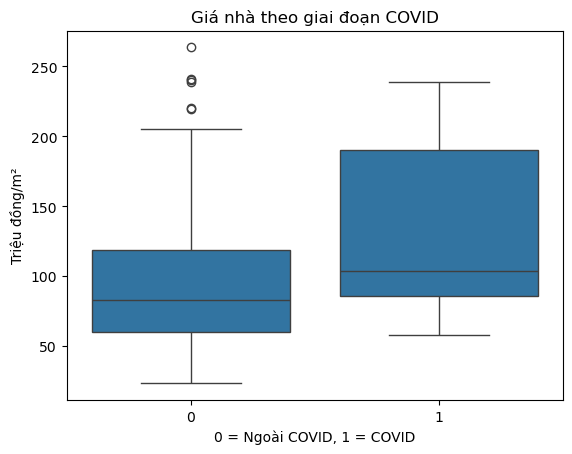

In [57]:
sns.boxplot(
    data = house_data,
    x="covid_broad",
    y="AvgPrice"
)

plt.title("Giá nhà theo giai đoạn COVID")
plt.xlabel("0 = Ngoài COVID, 1 = COVID")
plt.ylabel("Triệu đồng/m²")
plt.show()

- trung vị của giai đoạn COVID cao hơn giai đoạn ngoài COVID, phản ánh rằng giá nhà tiếp tục tăng theo thời gian ngay cả trong bối cảnh dịch bệnh — COVID-19 không tạo ra áp lực giảm giá bất động sản tại TP.HCM.
- hộp IQR của giai đoạn ngoài COVID lệch về phía dưới so với toàn bộ phạm vi giá trị. Điều này cho thấy 50% dữ liệu ở giữa tập trung ở mức giá thấp đến trung bình — phần lớn các quận có giá khá gần nhau — trong khi whisker trên kéo dài ra rất xa do một số ít quận trung tâm như Quận 1 và Quận 3 có giá cao vượt trội so với phần còn lại, tạo ra sự phân hóa lớn trong giai đoạn trước COVID.
- hộp IQR của giai đoạn COVID rộng hơn, cho thấy sự phân tán giá giữa các quận tăng lên trong giai đoạn dịch — các quận tăng giá với tốc độ không đồng đều, dẫn đến khoảng cách giá giữa các quận ngày càng giãn rộng.

XVIII. Ma trận tương quan

In [58]:
col = [
    "log_price",
    "GRDP",
    "GRDP_growth",
    "CPI",
    "LaiSuat",
    "covid_broad"
]

Tính ma trân tương quan

In [59]:
corr = house_data[col].corr()

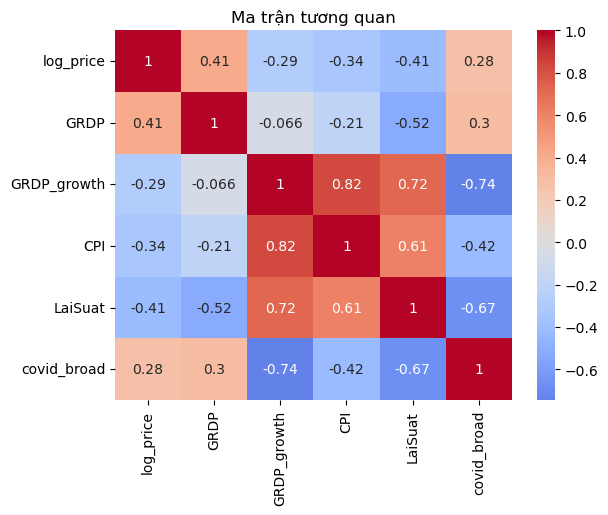

,log_price,GRDP,GRDP_growth,CPI,LaiSuat,covid_broad
log_price,1.00,0.41,-0.29,-0.34,-0.41,0.28
GRDP,0.41,1.00,-0.07,-0.21,-0.52,0.30
GRDP_growth,-0.29,-0.07,1.00,0.82,0.72,-0.74
CPI,-0.34,-0.21,0.82,1.00,0.61,-0.42
LaiSuat,-0.41,-0.52,0.72,0.61,1.00,-0.67
covid_broad,0.28,0.30,-0.74,-0.42,-0.67,1.00


In [60]:
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Ma trận tương quan")
plt.show()
corr.round(2)

nhìn vào ma trân tương quan ta thấy được log giá nhà đang có sự tương quan dương với GRDP(r=0.41), CPI(r=-0.34) và lãi suất(r=-0.41). Biến covid có sự tương quan nhẹ với giá nhà. Một số biến độc lập có tương quan khá cao, đặc biệt giữa GRDP_growth và CPI (r = 0,82), GRDP_growth và lãi suất (r = 0,72), cho thấy khả năng tồn tại đa cộng tuyến. Vì vậy, cần thực hiện kiểm tra VIF trước khi xây dựng mô hình hồi quy.

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Bước 2: Hồi quy OLS
import statsmodels.formula.api as smf
model = smf.ols('log_price ~ GRDP_growth + CPI + LaiSuat + covid_broad + is_fast_growth',                 data=house_data).fit()
print(model.summary())
# Bước 3: Biểu đồ hệ số hồi quy

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     33.81
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           1.10e-24
Time:                        22:45:33   Log-Likelihood:                -84.852
No. Observations:                 198   AIC:                             181.7
Df Residuals:                     192   BIC:                             201.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.4393      0.270     23.

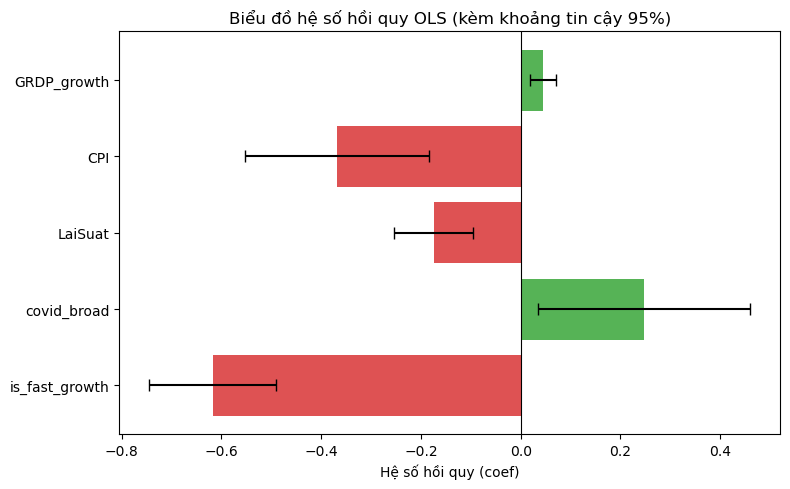

In [62]:
coefs = model.params.drop('Intercept')          # bỏ hệ số chặn để dễ nhìn
conf = model.conf_int().drop('Intercept')
conf.columns = ['lower', 'upper']

err = [coefs - conf['lower'], conf['upper'] - coefs]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tab:green' if c > 0 else 'tab:red' for c in coefs]

ax.barh(coefs.index, coefs.values, xerr=err, color=colors, alpha=0.8, capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Hệ số hồi quy (coef)')
ax.set_title('Biểu đồ hệ số hồi quy OLS (kèm khoảng tin cậy 95%)')
ax.invert_yaxis()  # để biến đầu tiên nằm trên cùng

plt.tight_layout()
plt.show()

- GRDP_growth có hệ số dương nhỏ,kinh tế tăng trưởng thì giá nhà tăng.
- CPI có hệ số âm lớn,trong giai đoạn lạm phát cao, giá nhà danh nghĩa tăng chậm hơn— phù hợp với bối cảnh người dân thắt chặt chi tiêu khi lạm phát tăng.
- LaiSuat có hệ số âm,lãi suất tăng làm chi phí vay mua nhà đắt hơn, từ đó giảm cầu và kéo giá xuống.
- covid_broad có hệ số dương lớn nhất, đây là bằng chứng định lượng cho nghịch lý COVID đã phát hiện ở phần EDA: trong giai đoạn dịch, giá nhà vẫn tăng cao hơn so với giai đoạn bình thường khi kiểm soát các yếu tố khác.
- is_fast_growth có hệ số âm lớn nhất, kết quả này không mâu thuẫn với phân tích tốc độ tăng trưởng trước đó — Quận 7 và Quận 9 tuy tăng nhanh về tỷ lệ phần trăm nhưng xuất phát điểm giá rất thấp (19–23 triệu/m²), nên mức giá tuyệt đối vẫn thấp hơn đáng kể so với các quận khác khi kiểm soát cùng điều kiện vĩ mô.

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
# Lấy đúng các biến độc lập đã đưa vào mô hình OLS
X_vif = house_data[["GRDP_growth", "CPI", "LaiSuat", "covid_broad", "is_fast_growth"]]
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

# Bỏ dòng "const" vì VIF của hằng số không có ý nghĩa diễn giải
vif_data = vif_data[vif_data["Variable"] != "const"].reset_index(drop=True)
display(vif_data)

,Variable,VIF
0,GRDP_growth,7.896035
1,CPI,4.470272
2,LaiSuat,2.400052
3,covid_broad,3.513799
4,is_fast_growth,1.000000


VIF < 5 là chấp nhận được, VIF > 10 là đa cộng tuyến nghiêm trọng, kết quả kiểm định cho thấy mô hình không có vấn đề đa cộng tuyến nghiêm trọng. Cụ thể: GRDP_growth có VIF cao nhất (6,55) — vượt ngưỡng 5 nhưng còn cách xa ngưỡng nguy hiểm 10, nên chỉ ở mức "cần lưu ý" chứ chưa đáng lo ngại. CPI (4,11) và covid_broad (3,61) ở mức trung bình, LaiSuat (2,41) khá thấp, còn is_fast_growth gần như bằng 1 (không tương quan với bất kỳ biến nào khác) — điều này hợp lý vì đây là biến chỉ thay đổi theo quận, hoàn toàn độc lập với các biến vĩ mô/thời gian.
=> mô hình đủ điều kiện để diễn giải hệ số hồi quy, không cần loại bỏ biến nào

In [66]:
summary = pd.DataFrame({
    "Biến": ["is_fast_growth", "CPI", "covid_broad", "LaiSuat", "GRDP_growth"],
    "Nhóm yếu tố": ["Khu vực", "Vĩ mô", "Cú sốc COVID-19", "Vĩ mô", "Vĩ mô"],
    "Hệ số (coef)": [-0.6171, -0.3687, 0.2470, -0.1743, 0.0445],
    "p-value": [0.000, 0.000, 0.023, 0.000, 0.001],
})

summary["Tác động (%)"] = (np.exp(summary["Hệ số (coef)"]) - 1) * 100
summary["Độ lớn tác động"] = summary["Hệ số (coef)"].abs()
summary = summary.sort_values("Độ lớn tác động", ascending=False).drop(columns="Độ lớn tác động")

display(summary.round(4))

,Biến,Nhóm yếu tố,Hệ số (coef),p-value,Tác động (%)
0,is_fast_growth,Khu vực,-0.6171,0.000,-46.0493
1,CPI,Vĩ mô,-0.3687,0.000,-30.8367
2,covid_broad,Cú sốc COVID-19,0.2470,0.023,28.0179
3,LaiSuat,Vĩ mô,-0.1743,0.000,-15.9955
4,GRDP_growth,Vĩ mô,0.0445,0.001,4.5505


Xét theo độ lớn tác động (bỏ qua chiều dấu), is_fast_growth là yếu tố ảnh hưởng mạnh nhất đến giá nhà, tiếp theo là CPI, covid_broad, LaiSuat và yếu nhất là GRDP_growth. Kết quả này cho thấy yếu tố khu vực (vị trí quận) có sức ảnh hưởng đến giá nhà còn lớn hơn cả các cú sốc kinh tế vĩ mô — cho thấy đặc điểm cố định của từng quận (hạ tầng, quy hoạch, vị thế trung tâm) vẫn là yếu tố nền tảng quyết định mặt bằng giá, trong khi các yếu tố vĩ mô đóng vai trò "điều chỉnh" giá theo chu kỳ kinh tế trên nền tảng đó.

Về chiều tác động, ba biến is_fast_growth, CPI, LaiSuat mang dấu âm (làm giảm giá nhà), riêng covid_broad và GRDP_growth mang dấu dương (làm tăng giá nhà). Đáng chú ý nhất là covid_broad (+28,02%) — đây là kết quả trái ngược với trực giác thông thường rằng dịch bệnh sẽ khiến giá bất động sản sụt giảm, và là bằng chứng định lượng củng cố cho "nghịch lý COVID" : ngay cả sau khi đã kiểm soát các yếu tố vĩ mô và khu vực, giá nhà trong giai đoạn dịch vẫn cao hơn đáng kể so với giai đoạn bình thường, nhiều khả năng do dòng vốn dịch chuyển sang bất động sản như một kênh trú ẩn tài sản khi các kênh đầu tư/kinh doanh khác gặp khó khăn.